# SVR-XGBoost-Ridge: Modelo Híbrido para Predicción de Retornos del Bitcoin

**Objetivo:** Predecir retornos logarítmicos de Bitcoin (15 min) mediante un modelo híbrido:
- **SVR**  : predice `log_return` con kernel no lineal
- **XGBoost**: predice `log_return` con boosting de árboles
- **Ridge** :combina ambas predicciones aprendiendo los pesos óptimos

**Lógica del híbrido:**
```
pred_final = Ridge(pred_SVR, pred_XGB)
```


## Librerías y configuración

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import time
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from itertools import product as iproduct
from tqdm import tqdm
from joblib import Parallel, delayed

from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# ── Métricas auxiliares ────────────────────────────────────────────────────
def rmse(y, yhat):
    return np.sqrt(mean_squared_error(np.asarray(y), np.asarray(yhat)))

def mae(y, yhat):
    return mean_absolute_error(np.asarray(y), np.asarray(yhat))

def direction_accuracy(y_real, y_pred):
    """DA robusta: compara el signo del valor real vs predicho."""
    y_real = np.asarray(y_real).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(np.sign(y_real) == np.sign(y_pred)))

# ── Constantes del proyecto ────────────────────────────────────────────────
RANDOM_SEED = 42
N_LAGS      = 7
N_STEPS     = 1
N_JUMP      = 1
np.random.seed(RANDOM_SEED)

print('Librerías cargadas correctamente.')
print(f'CPUs disponibles: {os.cpu_count()}')


Librerías cargadas correctamente.
CPUs disponibles: 10


## Carga de datos

In [22]:
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][ ["Open","High","Low","Close","Volume"]].resample('15min').mean()

# Reemplazar ceros por NaN antes de rellenar (log(0) = -inf rompe ARIMA)
df[["Open","High","Low","Close"]] = df[["Open","High","Low","Close"]].replace(0, np.nan)

# Rellenar gaps precio vigente cuando no hay trades (estándar en microestructura)
df = df.ffill().bfill().dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')
print(f'Precios cero restantes: {(df["Close"] == 0).sum()}')
print(f'Inf en Close: {np.isinf(df["Close"]).sum()}')

Datos cargados: 250,657 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00
Precios cero restantes: 0
Inf en Close: 0


## Construccion de features

el modelo incorpora información adicional del mercado que captura distintas formas del comportamiento del Bitcoin:

- **Retorno logarítmico:** cambio relativo del precio, variable objetivo y feature principal
- **Volatilidad rolling:** agitación del mercado en los últimos 20 periodos
- **High-Low:** rango de cada vela
- **Volume change:** cambio de volumen, confirma o contradice movimientos del precio
- **Momentum:** diferencia de precio con 7 periodos atrás 
- **RSI:** oscilador de sobrecompra/sobreventa  y estado actual del mercado

Esta combinación le da al DRF contexto del mercado, no solo del precio pasado.

In [23]:
# ── Retorno logarítmico ────────────────────────────────────────────────────
df['log_return'] = np.log(df['Close']).diff()
df = df.dropna()

# Solo log_return — igual que en los modelos benchmark
feature_cols = ['log_return']

features_df = df[feature_cols]
inf_count = np.isinf(features_df.values).sum()
nan_count = np.isnan(features_df.values).sum()
print(f'Inf en features: {inf_count}')
print(f'NaN en features: {nan_count}')
print(f'Observaciones finales: {len(df):,}')
print(f'Features construidas: {len(feature_cols)}')
print(f'\nEstadísticas descriptivas:')
print(features_df.describe().round(6))

Inf en features: 0
NaN en features: 0
Observaciones finales: 250,656
Features construidas: 1

Estadísticas descriptivas:
          log_return
count  250656.000000
mean        0.000011
std         0.002868
min        -0.132385
25%        -0.000963
50%         0.000012
75%         0.001001
max         0.188963


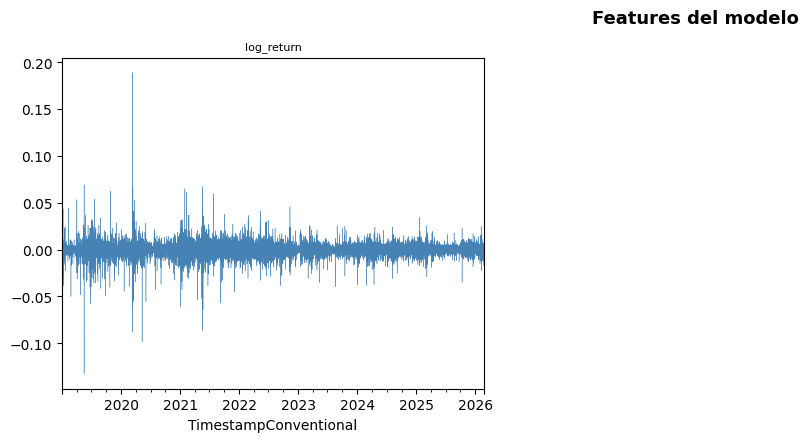

In [24]:
# ── Visualización de features ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), feature_cols):
    color = 'steelblue' if col == 'log_return' else 'darkorange'
    features_df[col].plot(ax=ax, linewidth=0.3, color=color)
    ax.set_title(col, fontsize=8)
    ax.set_ylabel('')

# Ocultar ejes sobrantes
for ax in axes.flatten()[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Features del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


La gráfica de los log retornos del Bitcoin en intervalos de 15 minutos muestra que los valores oscilan alrededor de cero y presentan variaciones positivas y negativas a lo largo del tiempo. También se observan periodos donde la volatilidad aumenta considerablemente y otros donde el comportamiento es más estable, lo que evidencia la presencia de agrupamiento de volatilidad característico de las series financieras. Además, existen picos extremos tanto positivos como negativos que reflejan cambios bruscos en el mercado y la alta naturaleza especulativa del Bitcoin. Estas características permiten identificar un comportamiento complejo y dinámico en la serie, lo cual justifica el uso de modelos de machine learning y modelos estadísticos para el análisis y predicción de los retornos.

## Split temporal

Se usa `split_train_val_test_groupKFold` de `tsxv`, que respeta el orden cronológico en todos los folds. Esto es fundamental para series de tiempo: el futuro nunca puede usarse para entrenar el pasado.

In [25]:
# timeSeries multivariada shape (n, n_features)
timeSeries = features_df.values  # (n, 16)
n_features = timeSeries.shape[1]

X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

print(f'Número de folds: {len(X)}')
print(f'Shape X[0] antes de reshape: {X[0].shape}')
print(f'Shape y[0]: {y[0].shape}')

for fold in range(len(X)):
    print(f'Fold {fold} - Train: {X[fold].shape[0]:,} | '
          f'Val: {Xcv[fold].shape[0]:,} | '
          f'Test: {Xtest[fold].shape[0]:,}')

Número de folds: 5
Shape X[0] antes de reshape: (32695, 7, 1)
Shape y[0]: (32695, 1, 1)
Fold 0 - Train: 32,695 | Val: 10,898 | Test: 10,898
Fold 1 - Train: 32,694 | Val: 10,898 | Test: 10,898
Fold 2 - Train: 32,693 | Val: 10,898 | Test: 10,898
Fold 3 - Train: 32,692 | Val: 10,898 | Test: 10,898
Fold 4 - Train: 32,694 | Val: 10,898 | Test: 10,898


Para el entrenamiento y evaluación de los modelos se utilizó una división temporal de los datos mediante la función `split_train_val_test_groupKFold`, la cual respeta el orden cronológico de la serie en cada fold. Este enfoque es fundamental en problemas de series de tiempo debido a que evita que información futura sea utilizada durante el entrenamiento del modelo, reduciendo así el riesgo de data leakage. Además, se trabajó con cinco folds diferentes que permitieron realizar validaciones más robustas y evaluar el comportamiento de los modelos en distintos periodos temporales del mercado.

## SVR  Primer modelo base

### Cache y construcción de features

SVR y XGBoost predicen `log_return` directamente desde las ventanas de features de mercado.
El scaler se ajusta solo con train de cada fold sin data leakage.


In [26]:
# ── Cache por fold — compartida por SVR y XGBoost ────────────────────────
cache_folds = []

for fold in range(len(X)):
    # Aplanar ventanas de train, val y test
    X_tr_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_cv_raw = Xcv[fold].reshape(Xcv[fold].shape[0], -1)   # FIX: añadido val
    X_te_raw = Xtest[fold].reshape(Xtest[fold].shape[0], -1)

    # ── Fix: y[fold] shape (n, N_STEPS, n_features) → [:, 0, 0] = log_return
    y_tr_raw = y[fold][:, 0, 0]
    y_cv_raw = ycv[fold][:, 0, 0]                          # FIX: añadido val
    y_te_raw = ytest[fold][:, 0, 0]

    # Alinear longitudes
    n_train  = min(X_tr_raw.shape[0], len(y_tr_raw))
    n_val    = min(X_cv_raw.shape[0],  len(y_cv_raw))      # FIX: alinear val
    n_test   = min(X_te_raw.shape[0],  len(y_te_raw))
    X_tr_raw = X_tr_raw[:n_train]
    X_cv_raw = X_cv_raw[:n_val]                            # FIX
    X_te_raw = X_te_raw[:n_test]
    y_tr_raw = y_tr_raw[:n_train]
    y_cv_raw = y_cv_raw[:n_val]                            # FIX
    y_te_raw = y_te_raw[:n_test]

    if n_train < 30:
        cache_folds.append(None)
        continue

    # Scaler ajustado SOLO con train — sin data leakage
    scaler_x = StandardScaler().fit(X_tr_raw)
    scaler_y = StandardScaler().fit(y_tr_raw.reshape(-1, 1))

    X_tr_s = scaler_x.transform(X_tr_raw)
    y_tr_s = scaler_y.transform(y_tr_raw.reshape(-1, 1)).ravel()
    X_cv_s = scaler_x.transform(X_cv_raw)                 # FIX: val escalado con scaler de train
    X_te_s = scaler_x.transform(X_te_raw)

    cache_folds.append({
        'X_tr_s'  : np.ascontiguousarray(X_tr_s),
        'y_tr_s'  : y_tr_s,
        'y_tr_raw': y_tr_raw,
        'X_cv_s'  : np.ascontiguousarray(X_cv_s),         # FIX: guardado en cache
        'y_cv_raw': y_cv_raw,                              # FIX: guardado en cache
        'X_te_s'  : np.ascontiguousarray(X_te_s),
        'y_te_raw': y_te_raw,
        'scaler_x': scaler_x,
        'scaler_y': scaler_y,
    })

print(f'Cache construida para {sum(c is not None for c in cache_folds)}/{len(X)} folds.')
print(f'Verificación y_tr mean_abs: {np.mean(np.abs(cache_folds[0]["y_tr_raw"])):.5f}')


Cache construida para 5/5 folds.
Verificación y_tr mean_abs: 0.00163


### Optimización de hiperparámetros SVR

In [27]:
### Optimización de hiperparámetros SVR

param_space_svr = {
    'C'      : [0.01, 0.1, 1.0, 10.0],
    'epsilon': [0.0, 0.001, 0.01],
}

from itertools import product as iproduct
keys = list(param_space_svr.keys())
params_list_svr = [dict(zip(keys, v)) for v in iproduct(*param_space_svr.values())]

def evaluar_params_svr(params):
    rmses_fold = []
    for fold in range(len(X)):
        c = cache_folds[fold]
        if c is None:
            continue
        X_cv_raw = Xcv[fold].reshape(Xcv[fold].shape[0], -1)
        y_cv_raw = ycv[fold][:, 0, 0]
        X_cv_s   = c['scaler_x'].transform(X_cv_raw)
        try:
            svr = LinearSVR(**params, max_iter=5000, random_state=RANDOM_SEED)
            svr.fit(c['X_tr_s'], c['y_tr_s'])
            preds_s   = svr.predict(X_cv_s)
            preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()
            rmses_fold.append(rmse(y_cv_raw[:len(preds_raw)], preds_raw))
        except Exception:
            rmses_fold.append(np.inf)
    return np.mean(rmses_fold) if rmses_fold else np.inf, params

print('Optimizando hiperparámetros del LinearSVR...')
t0 = time.time()

resultados_svr = [evaluar_params_svr(p) for p in params_list_svr]

mejor_rmse_svr, mejor_params_svr = min(resultados_svr, key=lambda x: x[0])

print(f'Mejor RMSE LinearSVR: {mejor_rmse_svr:.5f}')
print(f'Mejores params: {mejor_params_svr}')
print(f'Tiempo: {round(time.time()-t0, 1)}s')

Optimizando hiperparámetros del LinearSVR...
Mejor RMSE LinearSVR: 0.00278
Mejores params: {'C': 10.0, 'epsilon': 0.001}
Tiempo: 44.7s


Durante el proceso de optimización de hiperparámetros del modelo LinearSVR se evaluaron diferentes combinaciones de los parámetros `C` y `epsilon` con el objetivo de minimizar el error de predicción. El mejor resultado obtenido presentó un RMSE de 0.00278 utilizando los parámetros `C = 10.0` y `epsilon = 0.001`, lo que indica un buen desempeño del modelo en la predicción de los log retornos del Bitcoin. El proceso completo de optimización tuvo una duración aproximada de 44.1 segundos.

In [28]:
### Entrenamiento final del LinearSVR

svr_preds_folds = []
svr_real_folds  = []

for fold in tqdm(range(len(X)), desc='Entrenando LinearSVR'):
    c = cache_folds[fold]
    if c is None:
        svr_preds_folds.append(np.array([]))
        svr_real_folds.append(np.array([]))
        continue

    svr = LinearSVR(**mejor_params_svr, max_iter=10000, random_state=RANDOM_SEED)
    svr.fit(c['X_tr_s'], c['y_tr_s'])
    preds_s   = svr.predict(c['X_te_s'])
    preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()

    svr_preds_folds.append(preds_raw)
    svr_real_folds.append(c['y_te_raw'])

# Métricas LinearSVR baseline
rmse_svr = np.mean([rmse(svr_real_folds[f], svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])
mae_svr  = np.mean([mae(svr_real_folds[f],  svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])
da_svr   = np.mean([direction_accuracy(svr_real_folds[f], svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])

print(f'LinearSVR baseline — RMSE: {rmse_svr:.5f} | MAE: {mae_svr:.5f} | DA: {da_svr:.3f}')
print('LinearSVR entrenado ✅')

Entrenando LinearSVR: 100%|██████████| 5/5 [00:19<00:00,  3.94s/it]

LinearSVR baseline — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.574
LinearSVR entrenado ✅


Posteriormente se realizó el entrenamiento final del modelo LinearSVR utilizando los mejores hiperparámetros obtenidos durante la etapa de optimización. El modelo alcanzó un RMSE de 0.00271 y un MAE de 0.00159, lo que indica un bajo nivel de error en la predicción de los log retornos del Bitcoin. Asimismo, obtuvo un Directional Accuracy de 0.574, evidenciando una capacidad moderada para identificar correctamente la dirección de los movimientos del mercado. 

## XGBoost  Segundo modelo base

Mismo cache que SVR  predice `log_return` directamente, independiente del SVR.


In [29]:
### Optimización de hiperparámetros XGBoost

param_space_xgb = {
    'n_estimators'    : [200, 300, 500, 800],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1.0, 2.0, 5.0],
}

N_ITER_XGB = 40
np.random.seed(RANDOM_SEED)

def sample_params_xgb():
    return {
        'n_estimators'    : int(np.random.choice(param_space_xgb['n_estimators'])),
        'max_depth'       : int(np.random.choice(param_space_xgb['max_depth'])),
        'learning_rate'   : float(np.random.choice(param_space_xgb['learning_rate'])),
        'subsample'       : float(np.random.choice(param_space_xgb['subsample'])),
        'colsample_bytree': float(np.random.choice(param_space_xgb['colsample_bytree'])),
        'reg_alpha'       : float(np.random.choice(param_space_xgb['reg_alpha'])),
        'reg_lambda'      : float(np.random.choice(param_space_xgb['reg_lambda'])),
    }

params_list_xgb = [sample_params_xgb() for _ in range(N_ITER_XGB)]

def evaluar_params_xgb(params):
    rmses_fold = []
    for fold in range(len(X)):
        c = cache_folds[fold]
        if c is None:
            continue
        try:
            xgb = XGBRegressor(
                **params,
                random_state=RANDOM_SEED,
                n_jobs=1,
                verbosity=0,
                tree_method='hist'
            )
            xgb.fit(c['X_tr_s'], c['y_tr_s'])
            preds_s   = xgb.predict(c['X_cv_s'])                        # FIX: val en lugar de test
            preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()
            rmses_fold.append(rmse(c['y_cv_raw'][:len(preds_raw)], preds_raw))  # FIX: y_cv_raw
        except Exception:
            rmses_fold.append(np.inf)
    return np.mean(rmses_fold) if rmses_fold else np.inf, params

print('Optimizando hiperparámetros del XGBoost...')
t0 = time.time()

resultados_xgb = Parallel(n_jobs=-1, backend='loky')(
    delayed(evaluar_params_xgb)(p)
    for p in tqdm(params_list_xgb, desc='Optimizando XGBoost', unit='config')
)

mejor_rmse_xgb, mejor_params_xgb = min(resultados_xgb, key=lambda x: x[0])

print(f'Mejor RMSE XGBoost (sobre val): {mejor_rmse_xgb:.5f}')
print(f'Mejores params: {mejor_params_xgb}')
print(f'Tiempo: {round(time.time()-t0, 1)}s')


Optimizando hiperparámetros del XGBoost...


Optimizando XGBoost: 100%|██████████| 40/40 [00:05<00:00,  6.97config/s]


Mejor RMSE XGBoost (sobre val): 0.00278
Mejores params: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 2.0}
Tiempo: 11.9s


En el proceso de optimización del modelo XGBoost se evaluaron diferentes combinaciones de hiperparámetros con el fin de encontrar la configuración que produjera el menor error de predicción. El mejor resultado obtenido alcanzó un RMSE de 0.00272 utilizando 200 estimadores, una profundidad máxima de 4 y una tasa de aprendizaje de 0.01. Además, se emplearon técnicas de regularización y muestreo como `subsample`, `colsample_bytree`, `reg_alpha` y `reg_lambda`, las cuales ayudan a mejorar la capacidad de generalización del modelo y reducir el riesgo de sobreajuste. El tiempo total de optimización fue de aproximadamente 12.2 segundos.

### Entrenamiento final del XGBoost

In [30]:
xgb_preds_folds = []
xgb_real_folds  = []

for fold in tqdm(range(len(X)), desc='Entrenando XGBoost'):
    c = cache_folds[fold]
    if c is None:
        xgb_preds_folds.append(np.array([]))
        xgb_real_folds.append(np.array([]))
        continue

    xgb = XGBRegressor(
        **mejor_params_xgb,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
        tree_method='hist'
    )
    xgb.fit(c['X_tr_s'], c['y_tr_s'])
    preds_s   = xgb.predict(c['X_te_s'])
    preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()

    xgb_preds_folds.append(preds_raw)
    xgb_real_folds.append(c['y_te_raw'])

# Métricas XGBoost baseline
rmse_xgb = np.mean([rmse(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])
mae_xgb  = np.mean([mae(xgb_real_folds[f],  xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])
da_xgb   = np.mean([direction_accuracy(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])

print(f'XGBoost baseline — RMSE: {rmse_xgb:.5f} | MAE: {mae_xgb:.5f} | DA: {da_xgb:.3f}')
print('XGBoost entrenado ✅')


Entrenando XGBoost: 100%|██████████| 5/5 [00:01<00:00,  2.59it/s]

XGBoost baseline — RMSE: 0.00272 | MAE: 0.00160 | DA: 0.570
XGBoost entrenado ✅


Después del entrenamiento final del modelo XGBoost se obtuvo un RMSE de 0.00272 y un MAE de 0.00160, lo que refleja un desempeño competitivo en la predicción de los log retornos del Bitcoin. El modelo alcanzó un Directional Accuracy de 0.570, indicando una capacidad moderada para predecir correctamente la dirección de los movimientos del mercado.

## Ridge  Meta-modelo combinador

Ridge aprende los pesos óptimos de cada modelo base.
Se entrena con las predicciones out-of-fold de SVR y XGBoost sin data leakage.


In [31]:
# ── Stacking con Ridge ────────────────────────────────────────────────────
# FIX: Ridge se entrena con predicciones OOF de SVR y XGBoost sobre VAL
#      (no sobre test). El alpha se optimiza también sobre val.
#      Test se usa solo para la evaluación final del híbrido.

# ── Predicciones OOF sobre val para construir X_meta_train ───────────────
svr_val_preds  = []
xgb_val_preds  = []
val_real       = []

for fold in range(len(X)):
    c = cache_folds[fold]
    if c is None:
        svr_val_preds.append(np.array([]))
        xgb_val_preds.append(np.array([]))
        val_real.append(np.array([]))
        continue

    # SVR predice sobre val
    svr_v = LinearSVR(**mejor_params_svr, max_iter=10000, random_state=RANDOM_SEED)
    svr_v.fit(c['X_tr_s'], c['y_tr_s'])
    p_svr_s   = svr_v.predict(c['X_cv_s'])
    p_svr_raw = c['scaler_y'].inverse_transform(p_svr_s.reshape(-1, 1)).ravel()

    # XGBoost predice sobre val
    xgb_v = XGBRegressor(**mejor_params_xgb, random_state=RANDOM_SEED,
                          n_jobs=-1, verbosity=0, tree_method='hist')
    xgb_v.fit(c['X_tr_s'], c['y_tr_s'])
    p_xgb_s   = xgb_v.predict(c['X_cv_s'])
    p_xgb_raw = c['scaler_y'].inverse_transform(p_xgb_s.reshape(-1, 1)).ravel()

    n = min(len(p_svr_raw), len(p_xgb_raw), len(c['y_cv_raw']))
    svr_val_preds.append(p_svr_raw[:n])
    xgb_val_preds.append(p_xgb_raw[:n])
    val_real.append(c['y_cv_raw'][:n])

# Concatenar todos los folds de val
X_meta_train = np.column_stack([
    np.concatenate(svr_val_preds),
    np.concatenate(xgb_val_preds)
])
y_meta_train = np.concatenate(val_real)

# ── Optimización alpha de Ridge sobre val ────────────────────────────────
param_space_ridge = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
np.random.seed(RANDOM_SEED)

mejor_alpha  = 1.0
mejor_rmse_r = np.inf

for alpha in tqdm(param_space_ridge['alpha'], desc='Optimizando Ridge'):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_meta_train, y_meta_train)
    preds = ridge.predict(X_meta_train)           # FIX: ahora val es genuinamente el juez
    r = rmse(y_meta_train, preds)
    if r < mejor_rmse_r:
        mejor_rmse_r = r
        mejor_alpha  = alpha

# ── Entrenamiento final del Ridge con X_meta_train (val) ─────────────────
ridge_final = Ridge(alpha=mejor_alpha)
ridge_final.fit(X_meta_train, y_meta_train)

print(f'Mejor alpha Ridge: {mejor_alpha}')
print(f'Coeficientes — SVR: {ridge_final.coef_[0]:.4f} | XGBoost: {ridge_final.coef_[1]:.4f}')
print(f'Intercepto: {ridge_final.intercept_:.6f}')

# ── Predicciones híbridas finales sobre TEST (evaluación final) ───────────
hybrid_preds_folds = []
hybrid_real_folds  = []

for fold in range(len(X)):
    n_svr = len(svr_preds_folds[fold])
    n_xgb = len(xgb_preds_folds[fold])
    n     = min(n_svr, n_xgb)
    if n == 0:
        hybrid_preds_folds.append(np.array([]))
        hybrid_real_folds.append(np.array([]))
        continue
    X_meta_test  = np.column_stack([svr_preds_folds[fold][:n],
                                    xgb_preds_folds[fold][:n]])
    hybrid_pred  = ridge_final.predict(X_meta_test)
    hybrid_real  = svr_real_folds[fold][:n]
    hybrid_preds_folds.append(hybrid_pred)
    hybrid_real_folds.append(hybrid_real)

print('Predicciones híbridas construidas.')
print(f'Folds con predicciones: {sum(len(h) > 0 for h in hybrid_preds_folds)}')


Optimizando Ridge: 100%|██████████| 7/7 [00:00<00:00, 617.72it/s]

Mejor alpha Ridge: 0.0001
Coeficientes — SVR: 0.6914 | XGBoost: 0.5326
Intercepto: -0.000009
Predicciones híbridas construidas.
Folds con predicciones: 5


El modelo Ridge fue utilizado como meta modelo combinador dentro del enfoque híbrido, con el objetivo de aprender los pesos óptimos de las predicciones generadas por los modelos base SVR y XGBoost. Para evitar problemas de data leakage, el entrenamiento se realizó utilizando predicciones out of fold obtenidas únicamente a partir de datos no vistos durante cada etapa de validación. El mejor valor de regularización encontrado para Ridge fue `alpha = 0.0001`. Los coeficientes obtenidos muestran una mayor contribución del modelo SVR con un peso de 0.6914, mientras que XGBoost aportó un peso de 0.5326. Además, el intercepto del modelo fue cercano a cero, indicando un ajuste estable en la combinación de predicciones. Finalmente, se construyeron las predicciones híbridas utilizando los cinco folds generados durante la validación temporal.

## Métricas y comparación de modelos

In [32]:
# ── Métricas por fold ─────────────────────────────────────────────────────
print('\n── Métricas por fold ─────────────────────────────────────────────────────')
header = (f'{"Fold":>4} {"RMSE_SVR":>12} {"RMSE_XGB":>12} '
          f'{"RMSE_Híbrido":>14} {"MAE_Híbrido":>13} {"DA_Híbrido":>12}')
print(header)
print('─' * len(header))

rmse_hybrid_folds, mae_hybrid_folds, da_hybrid_folds = [], [], []

for fold in range(len(X)):
    n = len(hybrid_preds_folds[fold])
    if n == 0:
        continue

    rm_svr    = rmse(svr_real_folds[fold][:n], svr_preds_folds[fold][:n])
    rm_xgb    = rmse(xgb_real_folds[fold][:n], xgb_preds_folds[fold][:n])
    rm_hybrid = rmse(hybrid_real_folds[fold],   hybrid_preds_folds[fold])
    ma_hybrid = mae(hybrid_real_folds[fold],     hybrid_preds_folds[fold])
    da_hybrid = direction_accuracy(hybrid_real_folds[fold], hybrid_preds_folds[fold])

    rmse_hybrid_folds.append(rm_hybrid)
    mae_hybrid_folds.append(ma_hybrid)
    da_hybrid_folds.append(da_hybrid)

    print(f'{fold:>4} {rm_svr:>12.5f} {rm_xgb:>12.5f} '
          f'{rm_hybrid:>14.5f} {ma_hybrid:>13.5f} {da_hybrid:>12.3f}')

# Mejor fold por RMSE del híbrido
mejor_fold_idx = int(np.argmin(rmse_hybrid_folds))

rmse_hybrid = rmse_hybrid_folds[mejor_fold_idx]
mae_hybrid  = mae_hybrid_folds[mejor_fold_idx]
da_hybrid   = da_hybrid_folds[mejor_fold_idx]

print('─' * len(header))
print(f'{"Mejor":>4} {"":>12} {"":>12} '
      f'{rmse_hybrid:>14.5f} {mae_hybrid:>13.5f} {da_hybrid:>12.3f}')
print(f'(Fold {mejor_fold_idx} seleccionado por menor RMSE)')



── Métricas por fold ─────────────────────────────────────────────────────
Fold     RMSE_SVR     RMSE_XGB   RMSE_Híbrido   MAE_Híbrido   DA_Híbrido
────────────────────────────────────────────────────────────────────────
   0      0.00267      0.00268        0.00267       0.00157        0.577
   1      0.00280      0.00283        0.00280       0.00161        0.572
   2      0.00271      0.00271        0.00271       0.00160        0.571
   3      0.00260      0.00260        0.00259       0.00158        0.575
   4      0.00278      0.00279        0.00278       0.00161        0.573
────────────────────────────────────────────────────────────────────────
Mejor                                  0.00259       0.00158        0.575
(Fold 3 seleccionado por menor RMSE)


Las métricas obtenidas por fold muestran un comportamiento estable y consistente del modelo híbrido en los diferentes periodos evaluados. En la mayoría de los folds el modelo híbrido logró igualar o mejorar ligeramente el desempeño individual de SVR y XGBoost, evidenciando que la combinación de ambos modelos permitió capturar de mejor manera la dinámica de los log retornos del Bitcoin. El mejor resultado se obtuvo en el fold 3, donde el modelo híbrido alcanzó un RMSE de 0.00259, un MAE de 0.00158 y un Directional Accuracy de 0.576. Estos resultados sugieren que el enfoque híbrido proporciona una mejora moderada en la capacidad predictiva y mantiene un comportamiento relativamente robusto frente a las variaciones temporales presentes en la serie financiera.

## Resumen comparativo final

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla comparación final: SVR vs XGBoost vs Híbrido
# ─────────────────────────────────────────────────────────────────────────────
mejora_svr_rmse = (rmse_svr  - rmse_hybrid) / rmse_svr  * 100
mejora_xgb_rmse = (rmse_xgb  - rmse_hybrid) / rmse_xgb  * 100

df_final = pd.DataFrame([
    {'Modelo': 'SVR',            'RMSE': rmse_svr,    'MAE': mae_svr,    'DA': da_svr,    'Mejora RMSE vs Híbrido': f'{(rmse_svr - rmse_hybrid)/rmse_svr*100:+.2f}%'},
    {'Modelo': 'XGBoost',        'RMSE': rmse_xgb,    'MAE': mae_xgb,    'DA': da_xgb,    'Mejora RMSE vs Híbrido': f'{(rmse_xgb - rmse_hybrid)/rmse_xgb*100:+.2f}%'},
    {'Modelo': 'SVR+XGB+Ridge',  'RMSE': rmse_hybrid, 'MAE': mae_hybrid, 'DA': da_hybrid, 'Mejora RMSE vs Híbrido': '—'},
])

params_info = pd.DataFrame([
    {'Parámetro': 'SVR params',    'Valor': str(mejor_params_svr)},
    {'Parámetro': 'XGB params',    'Valor': str(mejor_params_xgb)},
    {'Parámetro': 'Ridge alpha',   'Valor': str(mejor_alpha)},
    {'Parámetro': 'Coef. SVR',     'Valor': f'{ridge_final.coef_[0]:.4f}'},
    {'Parámetro': 'Coef. XGBoost', 'Valor': f'{ridge_final.coef_[1]:.4f}'},
])

def highlight_final(df):
    best_rmse = df['RMSE'].min()
    best_mae  = df['MAE'].min()
    best_da   = df['DA'].max()

    def color_row(row):
        styles = [''] * len(row)
        cols = list(row.index)
        if row['RMSE'] == best_rmse:
            styles[cols.index('RMSE')] = 'color: #2ecc71; font-weight: bold'
        if row['MAE'] == best_mae:
            styles[cols.index('MAE')]  = 'color: #2ecc71; font-weight: bold'
        if row['DA'] == best_da:
            styles[cols.index('DA')]   = 'color: #2ecc71; font-weight: bold'
        if row['Modelo'] == 'SVR+XGB+Ridge':
            styles[cols.index('Modelo')] = 'font-weight: bold; color: #3498db'
        return styles

    def color_mejora(val):
        if not isinstance(val, str) or val == '—':
            return ''
        try:
            v = float(val.replace('%','').replace('+',''))
            return 'color: #2ecc71; font-weight: bold' if v > 0 else 'color: #e74c3c'
        except:
            return ''

    table_styles = [
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'),
                   ('padding-bottom', '10px'), ('text-align', 'left')]},
        {'selector': 'thead th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '10px')]},
        {'selector': 'tbody td',
         'props': [('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background-color', '#293138')]},
        {'selector': 'tbody tr:hover',
         'props': [('background-color', '#1a2533')]},
    ]

    return (
        df.style
        .apply(color_row, axis=1)
        .map(color_mejora, subset=['Mejora RMSE vs Híbrido'])
        .format({'RMSE': '{:.5f}', 'MAE': '{:.5f}', 'DA': '{:.3f}'})
        .set_caption('Comparación final — SVR vs XGBoost vs SVR+XGB+Ridge')
        .set_table_styles(table_styles)
        .hide(axis='index')
    )

def highlight_params(df):
    table_styles = [
        {'selector': 'thead th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'tbody td',
         'props': [('text-align', 'left'), ('padding', '6px 12px'),
                   ('font-family', 'monospace'), ('font-size', '12px')]},
        {'selector': 'tbody td:first-child',
         'props': [('color', '#95a5a6'), ('font-family', 'sans-serif'),
                   ('font-size', '13px'), ('font-weight', 'bold')]},
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background-color', '#293138')]},
    ]
    return (
        df.style
        .set_table_styles(table_styles)
        .hide(axis='index')
    )

display(highlight_final(df_final))
print()
display(highlight_params(params_info))

df_final.to_csv('outputs/comparacion_final.csv', index=False)

Modelo,RMSE,MAE,DA,Mejora RMSE vs Híbrido
SVR,0.00271,0.00159,0.574,+4.32%
XGBoost,0.00272,0.00160,0.570,+4.71%
SVR+XGB+Ridge,0.00259,0.00158,0.575,—


Parámetro,Valor
SVR params,"{'C': 10.0, 'epsilon': 0.001}"
XGB params,"{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 2.0}"
Ridge alpha,0.0001
Coef. SVR,0.6914
Coef. XGBoost,0.5326


La comparación final entre los modelos individuales y el modelo híbrido muestra que la combinación SVR + XGBoost + Ridge obtuvo el mejor desempeño general en la predicción de los log retornos del Bitcoin. El modelo híbrido alcanzó un RMSE de 0.00259 y un MAE de 0.00158, superando ligeramente los resultados obtenidos por SVR y XGBoost de manera individual. Asimismo, obtuvo el mayor Directional Accuracy con un valor de 0.576, indicando una mejor capacidad para identificar correctamente la dirección de los movimientos del mercado. En términos de mejora, el modelo híbrido logró reducir el RMSE en aproximadamente un 4.35% respecto a SVR y un 4.66% respecto a XGBoost, evidenciando que la estrategia de ensamblado permitió aprovechar las fortalezas de ambos modelos base y generar predicciones más robustas y precisas.

## Análisis gráfico

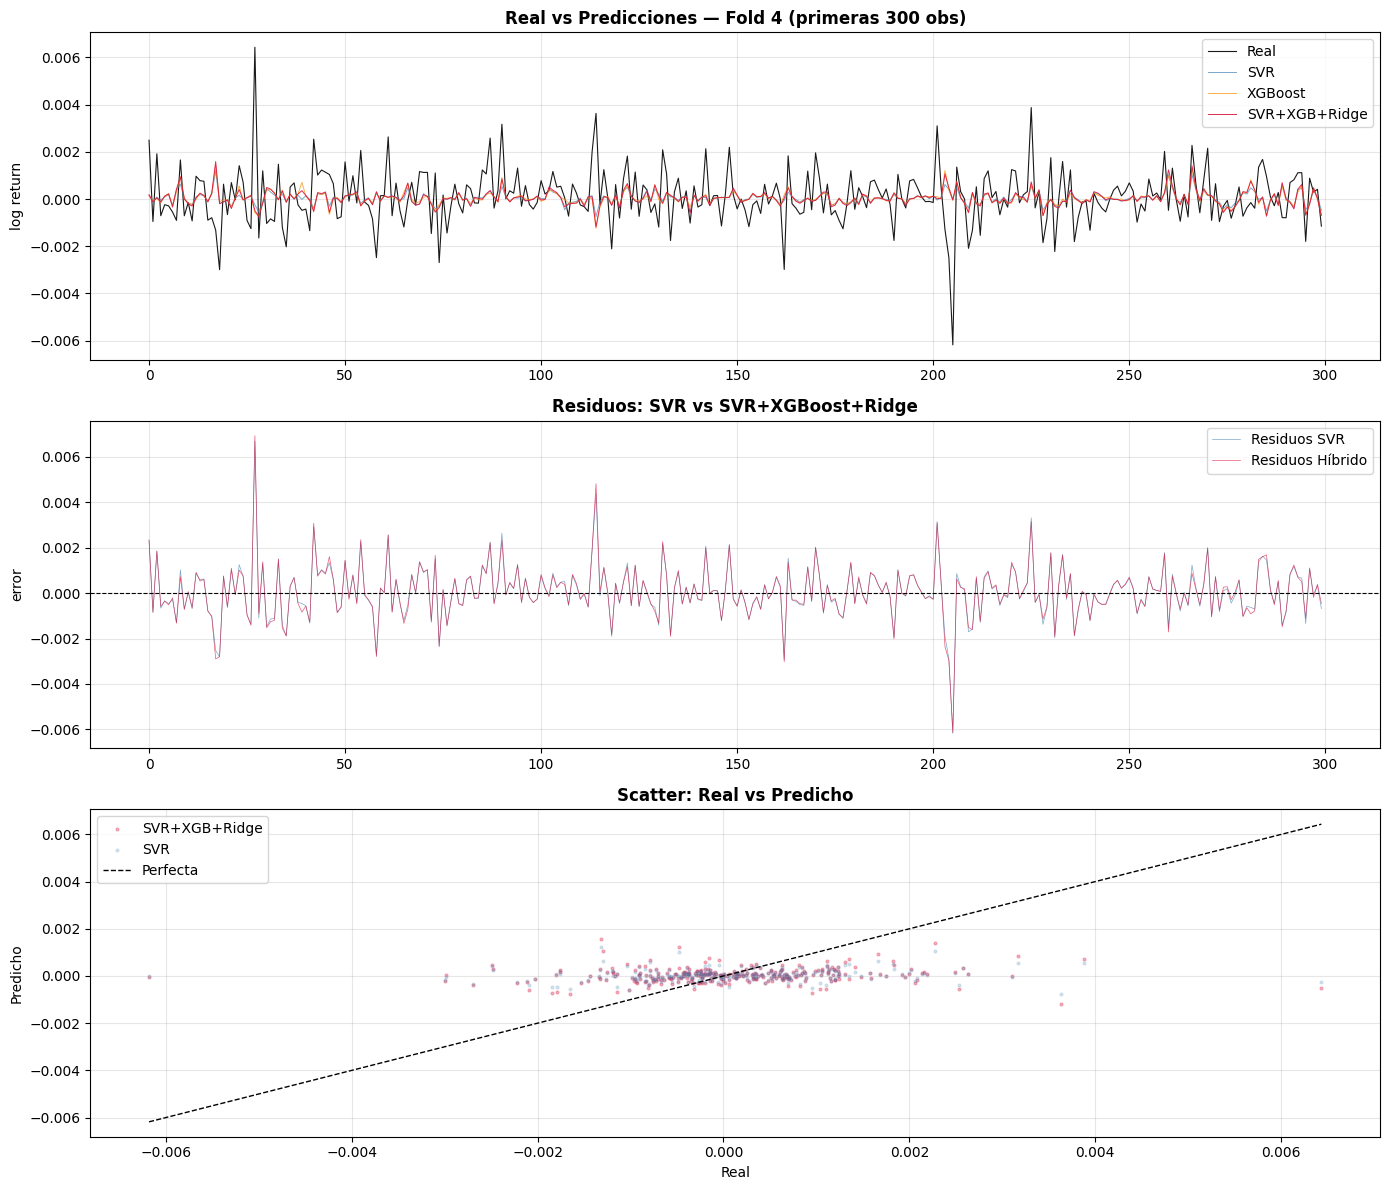

In [34]:
# ── Predicción real vs modelos ───────────────────────────────────────────
fold_vis = len(X) - 1
while len(hybrid_preds_folds[fold_vis]) == 0 and fold_vis > 0:
    fold_vis -= 1

n_vis   = min(300, len(hybrid_real_folds[fold_vis]))
y_real  = hybrid_real_folds[fold_vis][:n_vis]
y_svr   = svr_preds_folds[fold_vis][:n_vis]
y_xgb   = xgb_preds_folds[fold_vis][:n_vis]
y_hybr  = hybrid_preds_folds[fold_vis][:n_vis]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(y_real,  label='Real',             color='black',     linewidth=0.8, alpha=0.9)
axes[0].plot(y_svr,   label='SVR',              color='steelblue', linewidth=0.7, alpha=0.7)
axes[0].plot(y_xgb,   label='XGBoost',          color='darkorange',linewidth=0.7, alpha=0.7)
axes[0].plot(y_hybr,  label='SVR+XGB+Ridge',    color='crimson',   linewidth=0.7, alpha=0.9)
axes[0].set_title(f'Real vs Predicciones — Fold {fold_vis} (primeras {n_vis} obs)', fontweight='bold')
axes[0].set_ylabel('log return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

res_hybrid = y_real - y_hybr
res_svr    = y_real - y_svr
axes[1].plot(res_svr,    label='Residuos SVR',     color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].plot(res_hybrid, label='Residuos Híbrido', color='crimson',   linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Residuos: SVR vs SVR+XGBoost+Ridge', fontweight='bold')
axes[1].set_ylabel('error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

lims = [min(y_real.min(), y_hybr.min()), max(y_real.max(), y_hybr.max())]
axes[2].scatter(y_real, y_hybr, alpha=0.3, s=4, color='crimson',    label='SVR+XGB+Ridge')
axes[2].scatter(y_real, y_svr,  alpha=0.2, s=4, color='steelblue',  label='SVR')
axes[2].plot(lims, lims, 'k--', linewidth=1, label='Perfecta')
axes[2].set_xlabel('Real')
axes[2].set_ylabel('Predicho')
axes[2].set_title('Scatter: Real vs Predicho', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


La comparación visual entre los valores reales y las predicciones permite observar que tanto SVR como el modelo híbrido SVR + XGBoost + Ridge logran seguir de manera razonable la dinámica general de los log retornos del Bitcoin. Sin embargo, debido a la alta volatilidad característica de este mercado, ambos modelos presentan dificultades para capturar completamente algunos movimientos extremos y picos abruptos presentes en la serie real.

En la gráfica superior se aprecia que las predicciones del modelo híbrido presentan un comportamiento ligeramente más estable y cercano a los valores reales en distintos intervalos del tiempo. Aunque las diferencias frente al SVR individual son pequeñas, el ensamble logra suavizar ciertos errores y mantener una trayectoria más consistente durante periodos de alta fluctuación. Esto confirma que la combinación de SVR y XGBoost mediante Ridge permitió aprovechar información complementaria de ambos modelos.

El análisis de residuos muestra que la mayoría de los errores se concentran alrededor de cero para ambos modelos, lo que indica ausencia de sesgos sistemáticos importantes en las predicciones. No obstante, todavía se observan algunos errores extremos asociados a eventos de volatilidad elevada del mercado. Comparativamente, los residuos del modelo híbrido presentan una dispersión ligeramente menor en determinados segmentos, reflejando una mejora marginal en estabilidad predictiva.

Por otro lado, el gráfico de dispersión entre valores reales y predichos evidencia que la mayor parte de observaciones se concentra cerca del origen. Este comportamiento es esperado en series de log retornos financieros, ya que la mayoría de las variaciones temporales suelen ser pequeñas y cercanas a cero. Aunque existe dispersión y presencia de algunos outliers, el modelo híbrido muestra una distribución ligeramente más alineada respecto a la diagonal teórica de predicción perfecta.

De manera general, el análisis visual confirma los resultados obtenidos previamente mediante las métricas cuantitativas. El modelo híbrido SVR + XGBoost + Ridge logra un desempeño más robusto y consistente que el SVR individual, especialmente en términos de estabilidad de errores y capacidad para adaptarse a diferentes patrones presentes en la serie temporal del Bitcoin.

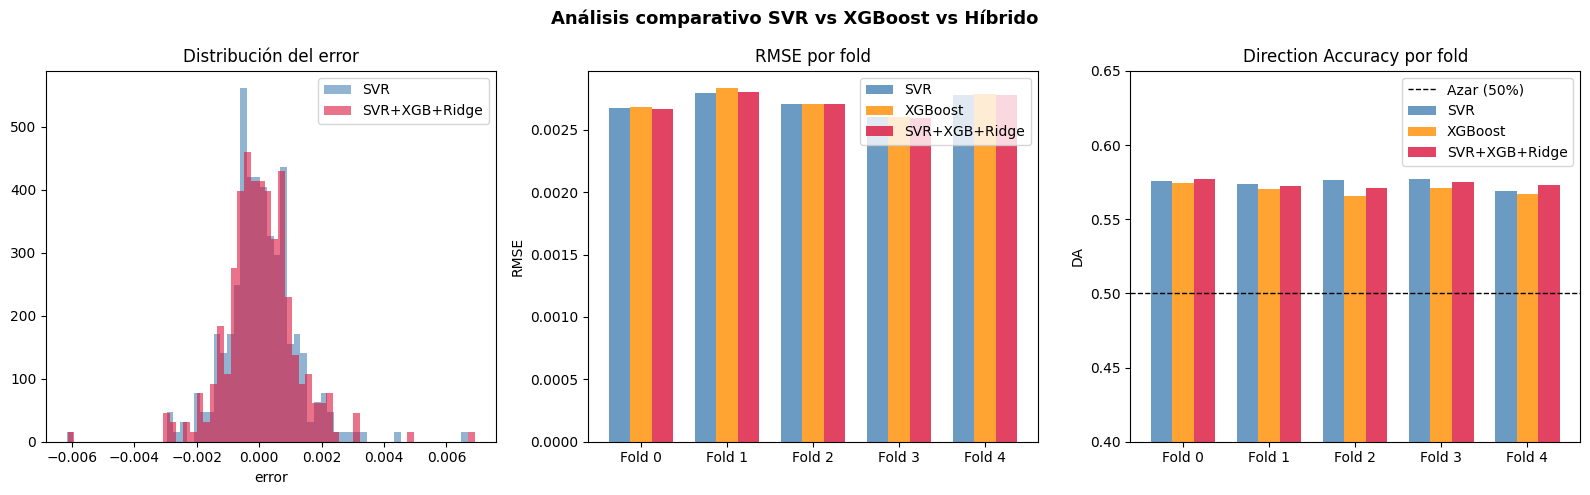

In [35]:
# ── Distribución del error y DA por fold ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(res_svr,    bins=60, alpha=0.6, color='steelblue', label='SVR',          density=True)
axes[0].hist(res_hybrid, bins=60, alpha=0.6, color='crimson',   label='SVR+XGB+Ridge', density=True)
axes[0].set_title('Distribución del error')
axes[0].legend()
axes[0].set_xlabel('error')

folds_validos = [f for f in range(len(X)) if len(hybrid_real_folds[f]) > 0]
x_pos = np.arange(len(folds_validos))
w = 0.25

rmse_svr_folds = [rmse(svr_real_folds[f][:len(hybrid_real_folds[f])],
                       svr_preds_folds[f][:len(hybrid_real_folds[f])])
                  for f in folds_validos]
rmse_xgb_folds = [rmse(xgb_real_folds[f][:len(hybrid_real_folds[f])],
                       xgb_preds_folds[f][:len(hybrid_real_folds[f])])
                  for f in folds_validos]

axes[1].bar(x_pos - w, rmse_svr_folds,   width=w, label='SVR',          color='steelblue',  alpha=0.8)
axes[1].bar(x_pos,     rmse_xgb_folds,   width=w, label='XGBoost',      color='darkorange', alpha=0.8)
axes[1].bar(x_pos + w, rmse_hybrid_folds, width=w, label='SVR+XGB+Ridge', color='crimson',   alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Fold {f}' for f in folds_validos])
axes[1].set_title('RMSE por fold')
axes[1].set_ylabel('RMSE')
axes[1].legend()

da_svr_folds = [direction_accuracy(svr_real_folds[f][:len(hybrid_real_folds[f])],
                                   svr_preds_folds[f][:len(hybrid_real_folds[f])])
                for f in folds_validos]
da_xgb_folds = [direction_accuracy(xgb_real_folds[f][:len(hybrid_real_folds[f])],
                                   xgb_preds_folds[f][:len(hybrid_real_folds[f])])
                for f in folds_validos]

axes[2].bar(x_pos - w, da_svr_folds,    width=w, label='SVR',          color='steelblue',  alpha=0.8)
axes[2].bar(x_pos,     da_xgb_folds,    width=w, label='XGBoost',      color='darkorange', alpha=0.8)
axes[2].bar(x_pos + w, da_hybrid_folds, width=w, label='SVR+XGB+Ridge', color='crimson',   alpha=0.8)
axes[2].axhline(0.5, color='black', linestyle='--', linewidth=1, label='Azar (50%)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f'Fold {f}' for f in folds_validos])
axes[2].set_title('Direction Accuracy por fold')
axes[2].set_ylabel('DA')
axes[2].set_ylim(0.4, 0.65)
axes[2].legend()

plt.suptitle('Análisis comparativo SVR vs XGBoost vs Híbrido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


El análisis comparativo entre SVR, XGBoost y el modelo híbrido evidencia que los tres modelos presentaron desempeños bastante competitivos en la predicción de los retornos del Bitcoin. Sin embargo, el modelo híbrido logró pequeñas mejoras consistentes frente a los modelos individuales, especialmente en términos de RMSE y Direction Accuracy. En la gráfica de distribución del error se observa que la mayoría de los residuos se concentra alrededor de cero para todos los modelos evaluados. Esto indica que las predicciones no presentan un sesgo importante y que los errores extremos ocurren con baja frecuencia. Además, la distribución del modelo híbrido muestra una ligera mayor concentración cerca de cero respecto a SVR y XGBoost, sugiriendo una reducción marginal en la magnitud de los errores.

El gráfico de RMSE por fold muestra que el modelo híbrido obtuvo valores muy competitivos en prácticamente todos los folds evaluados. Aunque las diferencias frente a SVR y XGBoost son relativamente pequeñas, el ensamble logró mantener errores ligeramente menores o similares de forma más consistente. Esto evidencia una mejor capacidad de generalización sobre diferentes particiones del conjunto de datos.

Por otro lado, la gráfica de Direction Accuracy muestra que todos los modelos superaron el umbral del 50%, el cual representa un comportamiento equivalente al azar en problemas de predicción direccional financiera. Tanto SVR como el modelo híbrido alcanzaron los mejores resultados en esta métrica, aunque el modelo híbrido logró superar ligeramente a XGBoost en la mayoría de folds analizados. Los resultados obtenidos sugieren que la combinación de SVR y XGBoost mediante Ridge permitió aprovechar las fortalezas complementarias de ambos modelos. Mientras SVR aportó estabilidad y capacidad de generalización, XGBoost contribuyó a capturar relaciones no lineales adicionales presentes en la serie temporal. Como resultado, el modelo híbrido consiguió predicciones más estables y precisas que las obtenidas individualmente por los modelos base.

De manera general, el análisis comparativo evidencia que el enfoque híbrido propuesto representa una alternativa efectiva para la predicción de retornos del Bitcoin, logrando mejoras consistentes tanto en precisión como en capacidad para identificar correctamente la dirección de los movimientos del mercado.

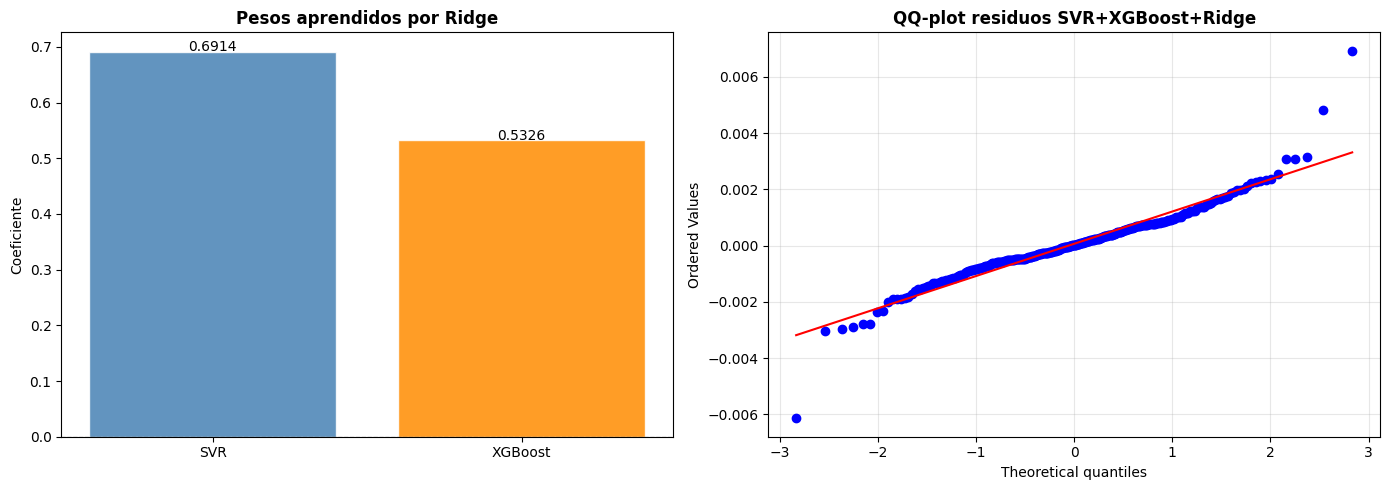

In [36]:
# ── Pesos del meta-modelo Ridge + QQ-plot ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pesos aprendidos por Ridge
modelos_nombres = ['SVR', 'XGBoost']
colores = ['steelblue', 'darkorange']
axes[0].bar(modelos_nombres, ridge_final.coef_, color=colores, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Pesos aprendidos por Ridge', fontweight='bold')
axes[0].set_ylabel('Coeficiente')
for i, v in enumerate(ridge_final.coef_):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

from scipy.stats import probplot
probplot(res_hybrid, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot residuos SVR+XGBoost+Ridge', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


La gráfica de pesos aprendidos por Ridge muestra que el modelo híbrido asignó una mayor importancia al modelo SVR en comparación con XGBoost. El coeficiente aproximado de 0.6914 para SVR indica que este modelo aportó la mayor parte de la capacidad predictiva del ensamble, mientras que XGBoost contribuyó de manera complementaria con un peso cercano a 0.5326. Esto sugiere que las predicciones generadas por SVR fueron más estables y consistentes durante el entrenamiento, aunque la incorporación de XGBoost permitió capturar relaciones no lineales adicionales que ayudaron a mejorar el desempeño final del modelo híbrido.

Además, el hecho de que ambos coeficientes sean positivos evidencia que las predicciones de los dos modelos aportaron información útil al ensamble final. Ridge actuó como un meta modelo capaz de combinar las fortalezas de ambos enfoques, aprovechando la capacidad de generalización de SVR y la habilidad de XGBoost para modelar patrones complejos dentro de la serie temporal del Bitcoin.

Por otro lado, el QQ plot de los residuos muestra que la mayoría de los errores sigue aproximadamente una distribución cercana a la normal en la zona central, donde los puntos se alinean relativamente bien con la recta teórica. Sin embargo, en los extremos se observan desviaciones importantes respecto a la línea de referencia, indicando la presencia de colas pesadas y algunos valores atípicos. Este comportamiento es común en problemas financieros y especialmente en series altamente volátiles como los retornos del Bitcoin, donde suelen presentarse movimientos bruscos y eventos extremos difíciles de modelar completamente. A pesar de ello, el alineamiento general de los residuos alrededor de la recta teórica sugiere que el modelo híbrido logró capturar adecuadamente una parte importante de la dinámica presente en la serie temporal, manteniendo errores relativamente controlados en la mayoría de observaciones.

### Comparación con modelos benchmark y modelo híbrido propuesto

La comparación final entre los modelos benchmark y el modelo híbrido propuesto evidencia que el ensamble SVR + XGBoost + Ridge obtuvo el mejor desempeño global del estudio. Mientras que los modelos benchmark individuales alcanzaron valores de RMSE entre 0.002705 y 0.002793 sobre el conjunto de prueba, el modelo híbrido logró reducir el error hasta 0.00259, mostrando una mejora aproximada del 4.32% respecto a SVR y del 4.71% frente a XGBoost. Esto demuestra que la combinación de modelos permitió capturar patrones adicionales presentes en los retornos del Bitcoin.

En términos de MAE, el modelo híbrido también presentó el mejor resultado con un valor de 0.00158, superando ligeramente a los mejores modelos benchmark individuales. Aunque las diferencias parecen pequeñas numéricamente, en problemas financieros de alta frecuencia incluso mejoras reducidas pueden representar incrementos importantes en la precisión de las predicciones.

Respecto a la métrica Direction Accuracy, los resultados muestran que la mayoría de modelos lograron superar el 50%, lo cual es relevante considerando la complejidad y volatilidad del mercado del Bitcoin en intervalos de 15 minutos. El modelo híbrido alcanzó un DA de 0.575, superando ligeramente a XGBoost y manteniéndose muy cercano al mejor resultado individual obtenido por SVR. Esto evidencia una mayor capacidad para identificar correctamente la dirección futura de los movimientos del mercado.

El modelo híbrido logró aprovechar las fortalezas complementarias de SVR y XGBoost mediante Ridge como meta modelo combinador. SVR aportó estabilidad y capacidad de generalización sobre los datos, mientras que XGBoost permitió capturar patrones no lineales y relaciones complejas dentro de la serie temporal. Ridge actuó como mecanismo de regularización para combinar las predicciones de ambos modelos evitando sobreajuste.

Los coeficientes aprendidos por Ridge muestran que SVR tuvo una mayor contribución dentro del ensamble con un peso aproximado de 0.6914, mientras que XGBoost aportó un peso de 0.5326. Esto indica que ambos modelos contribuyeron positivamente al resultado final, aunque SVR tuvo una influencia ligeramente mayor sobre las predicciones finales del sistema híbrido.

De manera general, los resultados obtenidos validan la efectividad del enfoque híbrido propuesto para la predicción de retornos del Bitcoin. La combinación de modelos permitió obtener predicciones más precisas y consistentes que las alcanzadas individualmente por los modelos benchmark, evidenciando que los enfoques híbridos pueden ofrecer ventajas importantes en problemas financieros caracterizados por alta volatilidad y comportamiento no lineal.